In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# 固定随机种子，保证实验尽量可重复
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 使用GPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# 读取处理好的数据表
metadata = pd.read_csv(
    "data/metadata/ravdess_prepared.csv"
)

train_df = metadata[
    metadata["split"] == "train"
].reset_index(drop=True)

validation_df = metadata[
    metadata["split"] == "validation"
].reset_index(drop=True)

test_df = metadata[
    metadata["split"] == "test"
].reset_index(drop=True)

emotion_names = [
    "neutral",
    "calm",
    "happy",
    "sad",
    "angry",
    "fearful",
    "disgust",
    "surprised",
]

print("Device:", device)
print("Train samples:", len(train_df))
print("Validation samples:", len(validation_df))
print("Test samples:", len(test_df))
print("Number of classes:", len(emotion_names))
print("Classes:", emotion_names)

Device: cuda
Train samples: 960
Validation samples: 240
Test samples: 240
Number of classes: 8
Classes: ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']


In [2]:
class RavdessDataset(Dataset):
    def __init__(self, dataframe):
        # 保存标签表，并重新整理行编号
        self.dataframe = dataframe.reset_index(drop=True)

    def __len__(self):
        # 返回这个数据集中有多少个样本
        return len(self.dataframe)

    def __getitem__(self, index):
        # 取得第index行的信息
        row = self.dataframe.iloc[index]

        # 读取已经生成的Log-Mel频谱
        feature = np.load(
            row["feature_path"]
        ).astype(np.float32)

        # NumPy数组 → PyTorch张量
        # 原始形状：(128, 126)
        # 添加通道后：(1, 128, 126)
        feature = torch.from_numpy(feature).unsqueeze(0)

        # 读取情绪标签0～7
        label = torch.tensor(
            int(row["label_id"]),
            dtype=torch.long
        )

        return feature, label

In [3]:
# 创建三个Dataset
train_dataset = RavdessDataset(train_df)
validation_dataset = RavdessDataset(validation_df)
test_dataset = RavdessDataset(test_df)

BATCH_SIZE = 32

# 固定训练集随机打乱的顺序
data_generator = torch.Generator()
data_generator.manual_seed(SEED)

# 创建三个DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=data_generator
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# 取出第一批数据进行检查
batch_features, batch_labels = next(iter(train_loader))

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(validation_dataset))
print("Test dataset size:", len(test_dataset))

print("\nNumber of training batches:", len(train_loader))
print("Number of validation batches:", len(validation_loader))
print("Number of test batches:", len(test_loader))

print("\nFeature batch shape:", batch_features.shape)
print("Label batch shape:", batch_labels.shape)
print("Feature minimum:", batch_features.min().item())
print("Feature maximum:", batch_features.max().item())
print("First 10 labels:", batch_labels[:10].tolist())

Train dataset size: 960
Validation dataset size: 240
Test dataset size: 240

Number of training batches: 30
Number of validation batches: 8
Number of test batches: 8

Feature batch shape: torch.Size([32, 1, 128, 126])
Label batch shape: torch.Size([32])
Feature minimum: 0.0
Feature maximum: 1.0
First 10 labels: [2, 6, 7, 2, 5, 5, 6, 1, 3, 5]


In [4]:
class ScratchCNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()

        self.features = nn.Sequential(
            # 输入：(1, 128, 126)
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # 大约：(16, 64, 63)
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # 大约：(32, 32, 31)
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # 大约：(64, 16, 15)
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # 将每个通道压缩为一个代表值
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [5]:
model = ScratchCNN(
    num_classes=len(emotion_names)
).to(device)

# 用一个假样本检查数据能否通过CNN
dummy_input = torch.zeros(
    1, 1, 128, 126
).to(device)

model.eval()

with torch.no_grad():
    dummy_output = model(dummy_input)

model.train()

# 统计可以训练的参数数量
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(model)
print("\nModel device:",
      next(model.parameters()).device)
print("Input shape:", dummy_input.shape)
print("Output shape:", dummy_output.shape)
print("Trainable parameters:", trainable_parameters)

ScratchCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

In [6]:
class RavdessDataset(Dataset):
    def __init__(self, dataframe, augment=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.dataframe)

    def apply_spec_augment(self, feature):
        feature = feature.copy()

        frequency_size, time_size = feature.shape

        # 随机遮挡1～8个频率区域
        frequency_width = random.randint(1, 8)
        frequency_start = random.randint(
            0,
            frequency_size - frequency_width
        )

        feature[
            frequency_start:
            frequency_start + frequency_width,
            :
        ] = 0.0

        # 随机遮挡1～12个时间区域
        time_width = random.randint(1, 12)
        time_start = random.randint(
            0,
            time_size - time_width
        )

        feature[
            :,
            time_start:
            time_start + time_width
        ] = 0.0

        return feature

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        feature = np.load(
            row["feature_path"]
        ).astype(np.float32)

        # 只在训练集使用数据增强
        if self.augment:
            feature = self.apply_spec_augment(feature)

        feature = torch.from_numpy(feature).unsqueeze(0)

        label = torch.tensor(
            int(row["label_id"]),
            dtype=torch.long
        )

        return feature, label

In [7]:
# 只有训练集开启增强
train_dataset = RavdessDataset(
    train_df,
    augment=True
)

validation_dataset = RavdessDataset(
    validation_df,
    augment=False
)

test_dataset = RavdessDataset(
    test_df,
    augment=False
)

data_generator = torch.Generator()
data_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    generator=data_generator
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

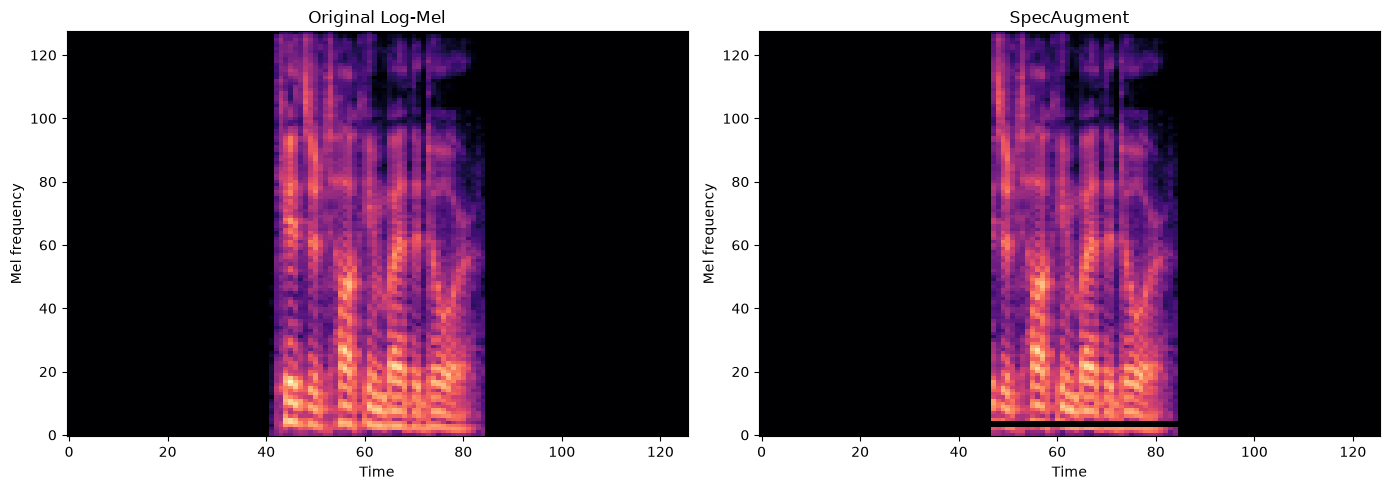

Original shape: (128, 126)
Augmented shape: (128, 126)
Label ID: 0
Emotion: neutral


In [8]:
original_feature = np.load(
    train_df.iloc[0]["feature_path"]
)

augmented_feature, augmented_label = train_dataset[0]
augmented_feature = augmented_feature.squeeze(0).numpy()

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5)
)

axes[0].imshow(
    original_feature,
    origin="lower",
    aspect="auto",
    cmap="magma",
    vmin=0,
    vmax=1
)
axes[0].set_title("Original Log-Mel")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Mel frequency")

axes[1].imshow(
    augmented_feature,
    origin="lower",
    aspect="auto",
    cmap="magma",
    vmin=0,
    vmax=1
)
axes[1].set_title("SpecAugment")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Mel frequency")

plt.tight_layout()
plt.show()

print("Original shape:", original_feature.shape)
print("Augmented shape:", augmented_feature.shape)
print("Label ID:", augmented_label.item())
print("Emotion:", emotion_names[augmented_label.item()])

In [9]:
# 统计训练集中每个情绪的样本数量
class_counts = (
    train_df
    .groupby("label_id")
    .size()
    .reindex(range(len(emotion_names)))
)

# 根据样本数量计算类别权重
class_weights = (
    len(train_df) /
    (len(emotion_names) * class_counts.values)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

print("Class distribution and weights:")

for class_id, emotion in enumerate(emotion_names):
    print(
        f"{class_id}: {emotion:10s} "
        f"samples={class_counts.iloc[class_id]:3d}, "
        f"weight={class_weights[class_id].item():.4f}"
    )

Class distribution and weights:
0: neutral    samples= 64, weight=1.8750
1: calm       samples=128, weight=0.9375
2: happy      samples=128, weight=0.9375
3: sad        samples=128, weight=0.9375
4: angry      samples=128, weight=0.9375
5: fearful    samples=128, weight=0.9375
6: disgust    samples=128, weight=0.9375
7: surprised  samples=128, weight=0.9375


In [10]:
# 加权交叉熵损失
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# AdamW优化器
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

# 如果验证损失连续3轮没有改善，
# 就把学习率乘以0.5
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [11]:
check_features, check_labels = next(
    iter(train_loader)
)

check_features = check_features.to(device)
check_labels = check_labels.to(device)

model.eval()

with torch.no_grad():
    check_outputs = model(check_features)
    check_loss = criterion(
        check_outputs,
        check_labels
    )

model.train()

print("\nOutput shape:", check_outputs.shape)
print("Initial loss:", check_loss.item())
print(
    "Current learning rate:",
    optimizer.param_groups[0]["lr"]
)


Output shape: torch.Size([32, 8])
Initial loss: 2.080132484436035
Current learning rate: 0.001


In [12]:
def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    # 开启训练模式：
    # BatchNorm和Dropout按照训练方式工作
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for features, labels in data_loader:
        features = features.to(
            device,
            non_blocking=True
        )
        labels = labels.to(
            device,
            non_blocking=True
        )

        # 清除上一批数据产生的梯度
        optimizer.zero_grad(set_to_none=True)

        # 前向传播：CNN输出8个情绪分数
        outputs = model(features)

        # 计算预测误差
        loss = criterion(outputs, labels)

        # 反向传播：计算每个参数应该怎样修改
        loss.backward()

        # 根据梯度更新模型参数
        optimizer.step()

        # 统计这一批的损失
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size

        # 分数最高的位置就是预测类别
        predictions = outputs.argmax(dim=1)

        total_correct += (
            predictions == labels
        ).sum().item()

        total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = 100.0 * total_correct / total_samples

    return average_loss, accuracy

In [13]:
@torch.no_grad()
def evaluate(
    model,
    data_loader,
    criterion,
    device
):
    # 进入评估模式：
    # 关闭Dropout，固定BatchNorm
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for features, labels in data_loader:
        features = features.to(
            device,
            non_blocking=True
        )
        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(features)
        loss = criterion(outputs, labels)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size

        predictions = outputs.argmax(dim=1)

        total_correct += (
            predictions == labels
        ).sum().item()

        total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = 100.0 * total_correct / total_samples

    return average_loss, accuracy

In [14]:
initial_validation_loss, initial_validation_accuracy = evaluate(
    model,
    validation_loader,
    criterion,
    device
)

print(
    "Initial validation loss:",
    round(initial_validation_loss, 4)
)

print(
    "Initial validation accuracy:",
    round(initial_validation_accuracy, 2),
    "%"
)

print("Training and evaluation functions are ready.")

Initial validation loss: 2.0802
Initial validation accuracy: 13.33 %
Training and evaluation functions are ready.


In [15]:
import time
from pathlib import Path

MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8

model_path = Path("models/scratch_cnn_best.pt")
history_path = Path(
    "results/metrics/scratch_training_history.csv"
)

model_path.parent.mkdir(parents=True, exist_ok=True)
history_path.parent.mkdir(parents=True, exist_ok=True)

history = []

best_validation_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

training_start_time = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start_time = time.time()

    # 使用训练集学习
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # 使用验证集检查模型
    validation_loss, validation_accuracy = evaluate(
        model,
        validation_loader,
        criterion,
        device
    )

    # 验证损失停滞时自动降低学习率
    scheduler.step(validation_loss)

    current_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )

    epoch_time = time.time() - epoch_start_time

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "validation_loss": validation_loss,
        "validation_accuracy": validation_accuracy,
        "learning_rate": current_learning_rate,
        "epoch_time_seconds": epoch_time
    })

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_accuracy:6.2f}% | "
        f"Val loss: {validation_loss:.4f} | "
        f"Val acc: {validation_accuracy:6.2f}% | "
        f"LR: {current_learning_rate:.6f} | "
        f"Time: {epoch_time:.1f}s"
    )

    # 如果验证损失达到目前最好水平，就保存模型
    if validation_loss < best_validation_loss - 1e-4:
        best_validation_loss = validation_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "validation_loss": validation_loss,
            "validation_accuracy": validation_accuracy,
            "emotion_names": emotion_names
        }, model_path)

        print("  → Best model saved")

    else:
        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(
            f"\nEarly stopping: validation loss did not "
            f"improve for {EARLY_STOPPING_PATIENCE} epochs."
        )
        break

total_training_time = time.time() - training_start_time

# 保存每一轮的训练记录
history_df = pd.DataFrame(history)
history_df.to_csv(history_path, index=False)

print("\nTraining finished.")
print("Best epoch:", best_epoch)
print("Best validation loss:",
      round(best_validation_loss, 4))
print("Total training time:",
      round(total_training_time, 1),
      "seconds")
print("Best model saved to:",
      model_path.resolve())
print("History saved to:",
      history_path.resolve())

Epoch 01/50 | Train loss: 2.0252 | Train acc:  21.88% | Val loss: 3.1290 | Val acc:  13.33% | LR: 0.001000 | Time: 13.9s
  → Best model saved
Epoch 02/50 | Train loss: 1.8563 | Train acc:  28.96% | Val loss: 2.7577 | Val acc:  13.33% | LR: 0.001000 | Time: 1.6s
  → Best model saved
Epoch 03/50 | Train loss: 1.7474 | Train acc:  33.33% | Val loss: 1.7875 | Val acc:  28.75% | LR: 0.001000 | Time: 1.3s
  → Best model saved
Epoch 04/50 | Train loss: 1.6750 | Train acc:  36.25% | Val loss: 1.7739 | Val acc:  32.50% | LR: 0.001000 | Time: 1.4s
  → Best model saved
Epoch 05/50 | Train loss: 1.5877 | Train acc:  42.40% | Val loss: 2.4088 | Val acc:  21.67% | LR: 0.001000 | Time: 1.3s
Epoch 06/50 | Train loss: 1.5631 | Train acc:  42.50% | Val loss: 1.6217 | Val acc:  31.67% | LR: 0.001000 | Time: 1.6s
  → Best model saved
Epoch 07/50 | Train loss: 1.5013 | Train acc:  43.23% | Val loss: 1.6880 | Val acc:  39.17% | LR: 0.001000 | Time: 1.5s
Epoch 08/50 | Train loss: 1.4721 | Train acc:  46.88% 

In [16]:
checkpoint = torch.load(
    model_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Loaded best epoch:", checkpoint["epoch"])
print(
    "Best validation accuracy:",
    round(checkpoint["validation_accuracy"], 2),
    "%"
)

Loaded best epoch: 34
Best validation accuracy: 53.75 %


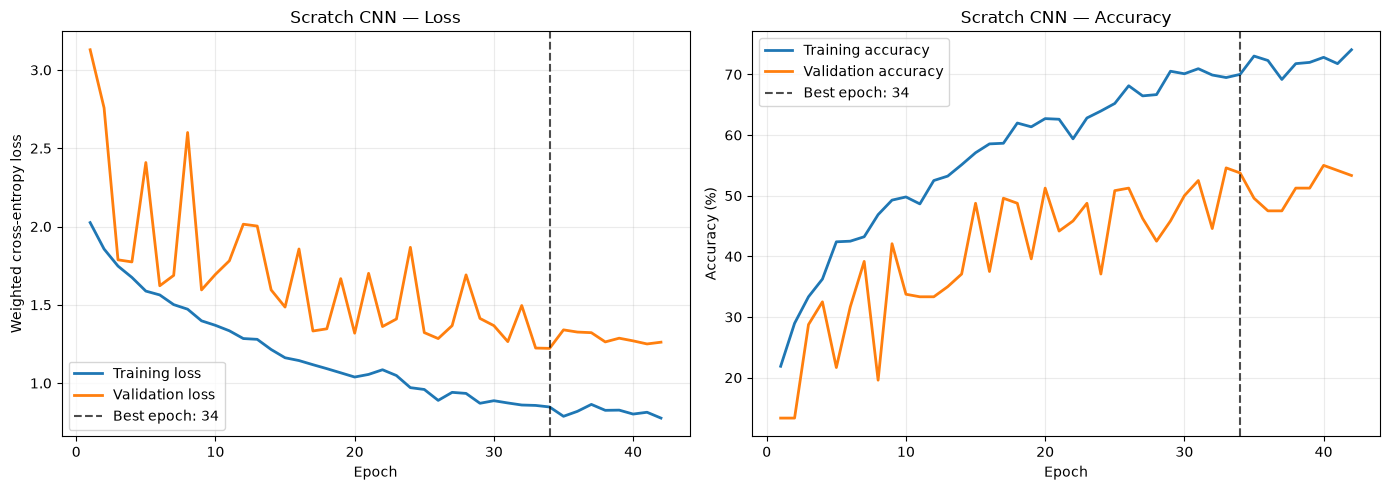

Best epoch: 34
Training accuracy at best epoch: 70.0 %
Validation accuracy at best epoch: 53.75 %
Figure saved to: D:\Robotique\Appentisage\CNN_Documents\results\figures\scratch_training_curves.png


In [17]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.read_csv(
    "results/metrics/scratch_training_history.csv"
)

best_epoch = checkpoint["epoch"]

figure_path = Path(
    "results/figures/scratch_training_curves.png"
)
figure_path.parent.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5)
)

# 损失曲线
axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training loss",
    linewidth=2
)

axes[0].plot(
    history_df["epoch"],
    history_df["validation_loss"],
    label="Validation loss",
    linewidth=2
)

axes[0].axvline(
    best_epoch,
    color="black",
    linestyle="--",
    alpha=0.7,
    label=f"Best epoch: {best_epoch}"
)

axes[0].set_title("Scratch CNN — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Weighted cross-entropy loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

# 准确率曲线
axes[1].plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Training accuracy",
    linewidth=2
)

axes[1].plot(
    history_df["epoch"],
    history_df["validation_accuracy"],
    label="Validation accuracy",
    linewidth=2
)

axes[1].axvline(
    best_epoch,
    color="black",
    linestyle="--",
    alpha=0.7,
    label=f"Best epoch: {best_epoch}"
)

axes[1].set_title("Scratch CNN — Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

best_row = history_df[
    history_df["epoch"] == best_epoch
].iloc[0]

print("Best epoch:", best_epoch)
print(
    "Training accuracy at best epoch:",
    round(best_row["train_accuracy"], 2),
    "%"
)
print(
    "Validation accuracy at best epoch:",
    round(best_row["validation_accuracy"], 2),
    "%"
)
print("Figure saved to:", figure_path.resolve())

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

@torch.no_grad()
def collect_predictions(
    model,
    data_loader,
    device
):
    model.eval()

    all_labels = []
    all_predictions = []

    for features, labels in data_loader:
        features = features.to(
            device,
            non_blocking=True
        )

        outputs = model(features)
        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(
            predictions.cpu().numpy()
        )

    return (
        np.array(all_labels),
        np.array(all_predictions)
    )

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

@torch.no_grad()
def collect_predictions(
    model,
    data_loader,
    device
):
    model.eval()

    all_labels = []
    all_predictions = []

    for features, labels in data_loader:
        features = features.to(
            device,
            non_blocking=True
        )

        outputs = model(features)
        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(
            predictions.cpu().numpy()
        )

    return (
        np.array(all_labels),
        np.array(all_predictions)
    )

In [20]:
# 计算测试损失和准确率
test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion,
    device
)

# 收集真实标签和预测标签
test_labels, test_predictions = collect_predictions(
    model,
    test_loader,
    device
)

macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro"
)

weighted_f1 = f1_score(
    test_labels,
    test_predictions,
    average="weighted"
)

print("Scratch CNN final test results")
print("--------------------------------")
print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 2), "%")
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))

Scratch CNN final test results
--------------------------------
Test loss: 1.3101
Test accuracy: 50.83 %
Macro F1: 0.4667
Weighted F1: 0.4671


In [21]:
report_text = classification_report(
    test_labels,
    test_predictions,
    labels=range(len(emotion_names)),
    target_names=emotion_names,
    digits=4,
    zero_division=0
)

print("\nClassification report:\n")
print(report_text)

report_dictionary = classification_report(
    test_labels,
    test_predictions,
    labels=range(len(emotion_names)),
    target_names=emotion_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dictionary
).transpose()

report_path = Path(
    "results/metrics/"
    "scratch_classification_report.csv"
)

report_df.to_csv(report_path)


Classification report:

              precision    recall  f1-score   support

     neutral     0.3333    0.7500    0.4615        16
        calm     0.6667    0.6875    0.6769        32
       happy     0.2600    0.4062    0.3171        32
         sad     0.6667    0.0625    0.1143        32
       angry     0.5000    0.5312    0.5152        32
     fearful     1.0000    0.1250    0.2222        32
     disgust     0.5882    0.6250    0.6061        32
   surprised     0.6957    1.0000    0.8205        32

    accuracy                         0.5083       240
   macro avg     0.5888    0.5234    0.4667       240
weighted avg     0.6059    0.5083    0.4671       240



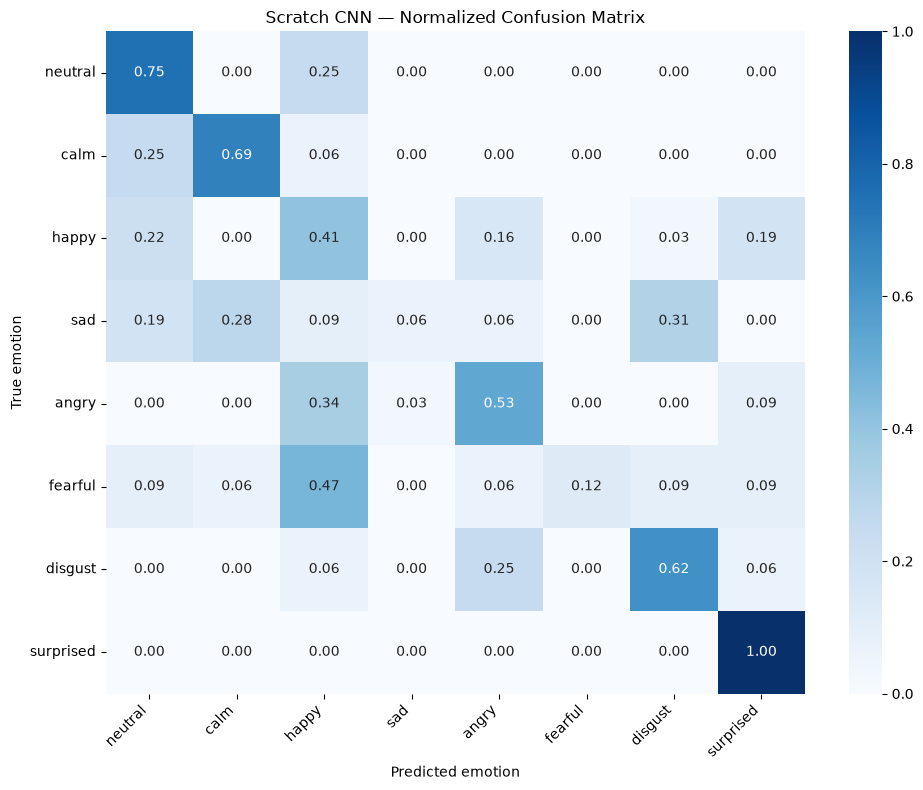

Report saved to: D:\Robotique\Appentisage\CNN_Documents\results\metrics\scratch_classification_report.csv
Confusion matrix saved to: D:\Robotique\Appentisage\CNN_Documents\results\figures\scratch_confusion_matrix.png


In [22]:
normalized_confusion_matrix = confusion_matrix(
    test_labels,
    test_predictions,
    labels=range(len(emotion_names)),
    normalize="true"
)

confusion_path = Path(
    "results/figures/"
    "scratch_confusion_matrix.png"
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    normalized_confusion_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=emotion_names,
    yticklabels=emotion_names,
    vmin=0,
    vmax=1
)

plt.title(
    "Scratch CNN — Normalized Confusion Matrix"
)
plt.xlabel("Predicted emotion")
plt.ylabel("True emotion")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(
    confusion_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Report saved to:", report_path.resolve())
print(
    "Confusion matrix saved to:",
    confusion_path.resolve()
)